Processing Text log: ../logs/training_logs/train_text_500.txt


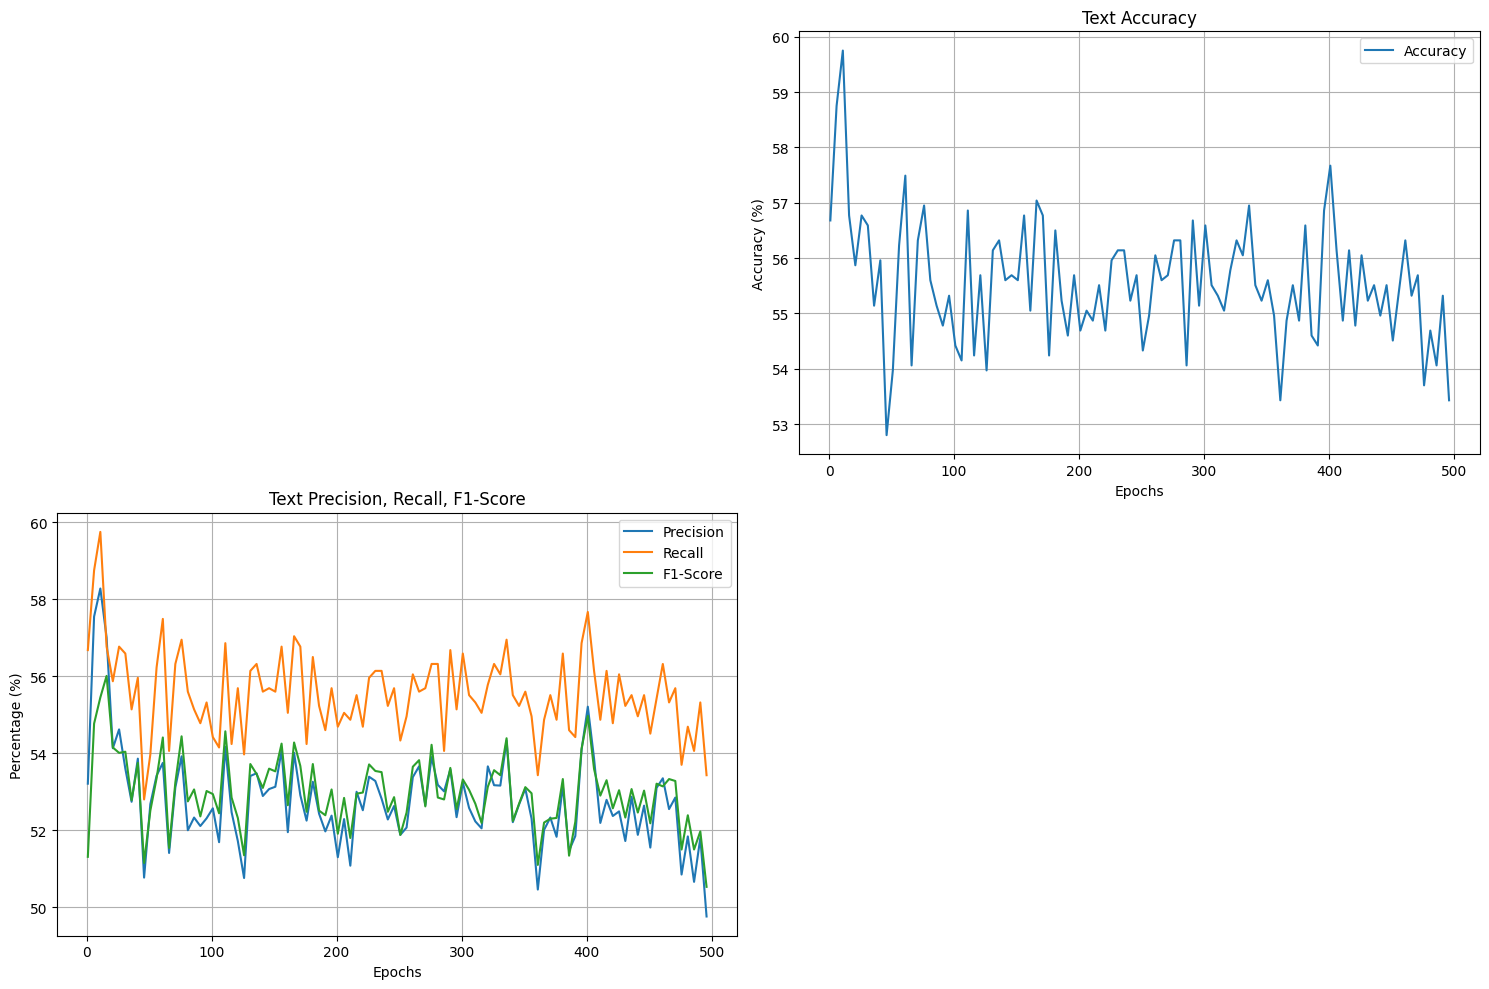




Processing Audio log: ../logs/training_logs/train_audio_500.txt


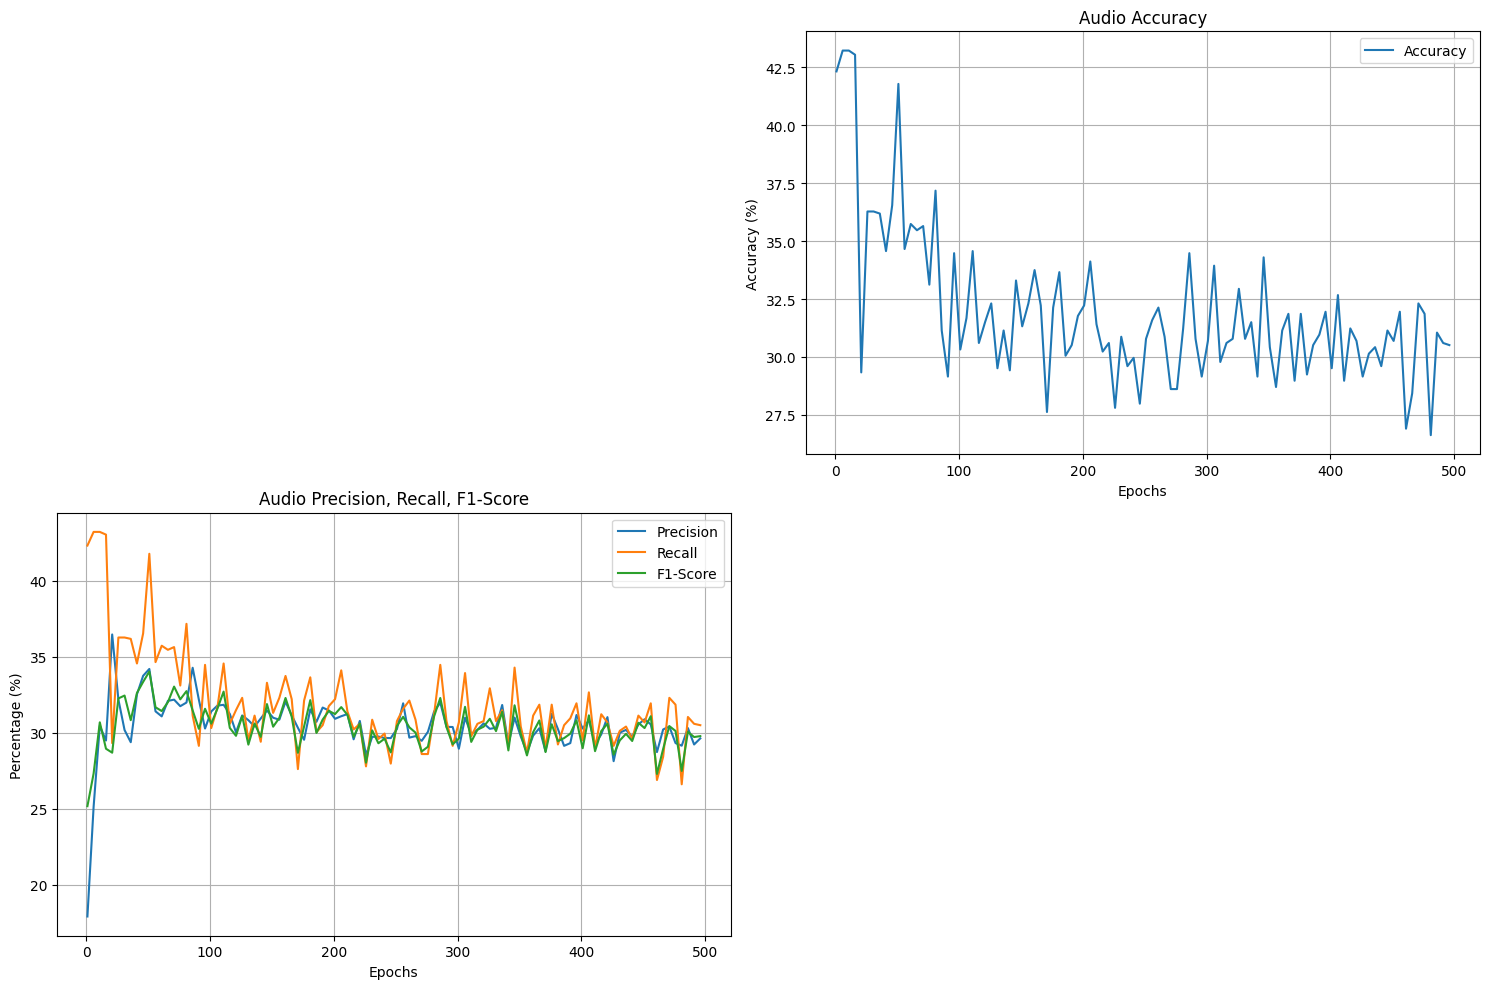




Processing Video log: ../logs/training_logs/train_video_500.txt


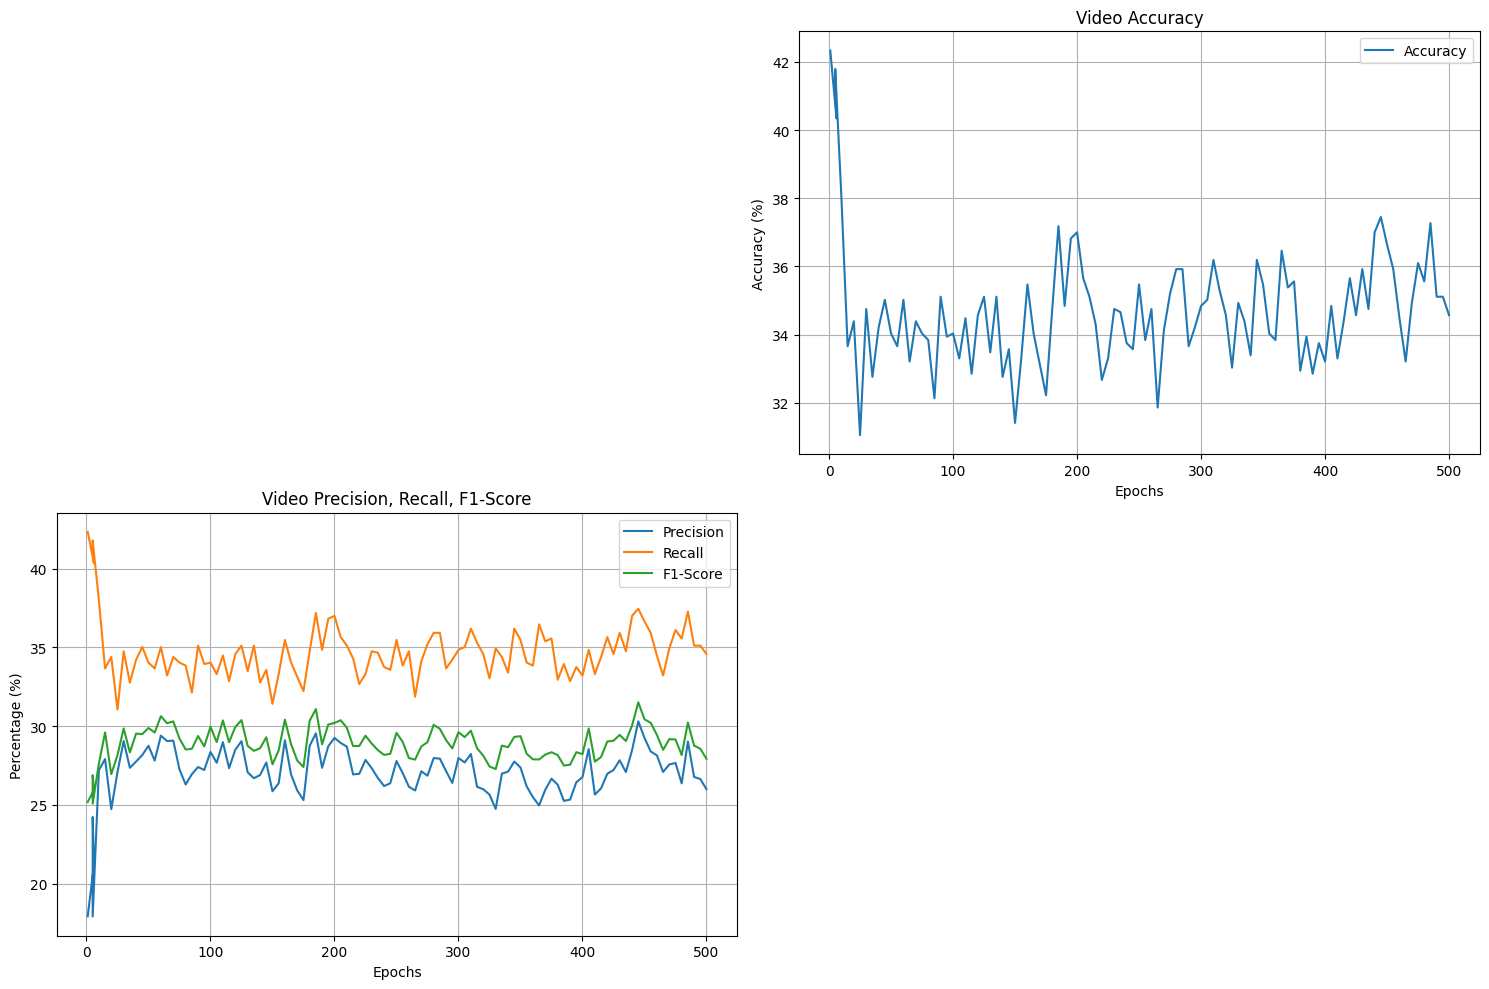

In [ ]:
import matplotlib.pyplot as plt

def parse_log_file(file_path):
    """
    Parse a log file to extract training metrics.
    Args:
        file_path (str): Path to the log file.
    Returns:
        dict: Parsed metrics (train_loss, val_loss, accuracy, precision, recall, f1_score).
    """
    epochs, train_loss, val_loss, accuracy, precision, recall, f1_score = [], [], [], [], [], [], []
    with open(file_path, "r") as file:
        for line in file:
            if "Epoch" in line and "Train Loss" in line:  # Ensure the line contains valid metrics
                try:
                    # Split the line into components
                    parts = line.strip().split(", ")
                    epoch = int(parts[0].split("Epoch ")[1].split(":")[0].strip())
                    train_loss_val = float(parts[0].split("Train Loss = ")[1].strip())
                    val_loss_val = float(parts[1].split("Val Loss = ")[1].strip())
                    accuracy_val = float(parts[2].split("Val Accuracy = ")[1].replace("%", "").strip())
                    precision_val = float(parts[3].split("Precision = ")[1].replace("%", "").strip())
                    recall_val = float(parts[4].split("Recall = ")[1].replace("%", "").strip())
                    f1_val = float(parts[5].split("F1 = ")[1].replace("%", "").strip())

                    # Append parsed values
                    epochs.append(epoch)
                    train_loss.append(train_loss_val)
                    val_loss.append(val_loss_val)
                    accuracy.append(accuracy_val)
                    precision.append(precision_val)
                    recall.append(recall_val)
                    f1_score.append(f1_val)
                except (IndexError, ValueError) as e:
                    print(f"Skipping malformed line: {line.strip()} - Error: {str(e)}")
    return {
        "epochs": epochs,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
    }



def plot_metrics(metrics, title_prefix=""):
    """
    Plot metrics from the parsed log file, skipping points to reduce clutter.
    Args:
        metrics (dict): Parsed metrics dictionary.
        title_prefix (str): Prefix for plot titles.
    """
    epochs = metrics["epochs"]
    skip = 5  # Skip points to reduce clutter

    # Apply skipping logic to metrics
    epochs = epochs[::skip]
    train_loss = metrics["train_loss"][::skip]
    val_loss = metrics["val_loss"][::skip]
    accuracy = metrics["accuracy"][::skip]
    precision = metrics["precision"][::skip]
    recall = metrics["recall"][::skip]
    f1_score = metrics["f1_score"][::skip]

    plt.figure(figsize=(15, 10))


    # Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs, accuracy, label="Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid()

    # Precision, Recall, F1-Score
    plt.subplot(2, 2, 2)
    plt.plot(epochs, precision, label="Precision")
    plt.plot(epochs, recall, label="Recall")
    plt.plot(epochs, f1_score, label="F1-Score")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage (%)")
    plt.title(f"{title_prefix} Precision, Recall, F1-Score")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


# File paths
file_paths = {
    "Text": "../logs/training_logs/train_text_500.txt",
    "Audio": "../logs/training_logs/train_audio_500.txt",
    "Video": "../logs/training_logs/train_video_500.txt",
}

for modality, file_path in file_paths.items():
    print(f"Processing {modality} log: {file_path}")
    metrics = parse_log_file(file_path)
    plot_metrics(metrics, title_prefix=modality)
    print("\n\n")
